# HyperSIGMA few-shot evaluation

Prototype-based few-shot evaluation against a frozen HyperSIGMA dual-branch
encoder (SpatViT + SpecViT + SEM). Optionally loads an *adapted* checkpoint
produced by `scripts/adapt_hypersigma.py`; set `adapted_checkpoint`
to `"none"` for the unadapted ablation.

Everything for this run is written to
`experiments/<experiment_name>/evaluations/<eval_name>/`.

## Pipeline

1. **Parameters** — name the experiment / eval, point at checkpoints,
   choose few-shot hyperparameters.
2. **Imports / repo root** — chdir to the repo root and print the torch /
   CUDA environment.
3. **Download HyperSIGMA checkpoints** — pull `spat-vit-base.pth` and
   `spec-vit-base.pth` from the WHU-Sigma HuggingFace repo if they aren't
   already on disk. *(Fixes the `FileNotFoundError` you would otherwise
   hit when building the dual encoder.)*
4. **Fit spatial PCA** — fit (or load) the 144→3 PCA, print per-component
   explained variance, show before/after tensor shapes, an example pixel,
   per-class component means, and an RGB visualization.
5. **Inspect the dual-branch model** — build `HyperSIGMADual`, show
   parameter counts (trainable vs frozen) per submodule, and run a dummy
   forward to print every branch's output shape.
6. **Level-2 MAE adaptation** — train the small randomly-initialized
   components via masked HSI reconstruction. The cell prints config,
   verifies checkpoints, then summarizes train/val loss + saved files.
7. **Bootstrap experiment dir + run evaluation** — create
   `experiments/<name>/` and run the few-shot evaluation.
8. **Inspect evaluation results** — OA/AA/Kappa for both cosine and
   euclidean, per-class accuracy, and a listing of plot files written.

In [ ]:
# === Parameters ===
# ---------------------------------------------------------------------------
# Repo-root bootstrap so we can read per-dataset specs from the central
# registry (data/datasets/registry.py). Cell 2 repeats this; it is idempotent.
# ---------------------------------------------------------------------------
import os, sys
from pathlib import Path as _Path

_REPO = _Path.cwd()
while not (_REPO / "lib" / "experiments.py").exists():
    if _REPO.parent == _REPO:
        raise RuntimeError("Could not locate repo root containing lib/experiments.py")
    _REPO = _REPO.parent
os.chdir(_REPO)
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

from data.datasets import get_spec

# ---------------------------------------------------------------------------
# ONE knob: the dataset. Everything dataset-specific - band count, PCA paths,
# the adapt config, and the default experiment/eval names - is derived from the
# registry, so switching datasets is a single-line change.
# ---------------------------------------------------------------------------
dataset = "houston"            # "houston" | "trento" | "muufl"
spec = get_spec(dataset)

# n-way for the few-shot episodes. Same convention as notebooks/evaluate.ipynb:
#   "c" (or None / "all") -> C-way: use ALL classes for this dataset
#   an int (e.g. 5)       -> fixed N-way
# C-way is implemented by omitting n_way from eval_params, so the episode
# sampler falls back to every available class (exactly like evaluate.ipynb).
n_way = "c"
_NWAY_ALL = n_way in (None, "c", "C", "all")
_resolved_n_way = spec.num_classes if _NWAY_ALL else int(n_way)
_way_tag = f"C{spec.num_classes}way" if _NWAY_ALL else f"{_resolved_n_way}way"

# Episode shape (also feeds the auto-generated experiment/eval names below).
k_shot = 5
k_query = 100
num_episodes = 2000

# --------------------------------------------------------------------------
# Pipeline mode: ONE knob that drives both Step 5 training and Step 6b eval.
# --------------------------------------------------------------------------
# Choose one:
#   "spatial_only"  -> adapt only SpatViT random-init pieces;
#                      eval uses pooled SpatViT features ("spat_pool"); the
#                      SpecViT forward is skipped entirely at eval time.
#   "spectral_only" -> adapt only SpecViT random-init pieces;
#                      eval uses mean of SpecViT tokens ("spec_pool"); SpatViT
#                      forward is skipped.
#   "joint_sem"     -> adapt both branches + SEM (sum of 3 losses);
#                      eval uses the fused SEM 512-d feature ("fused"). Both
#                      branches run, then SEM fuses.
#
# Prototypes in Step 6b are mean(normalized features) over each class's
# support set, in whatever feature space the eval mode selects. So:
#   spatial_only  -> prototypes in 768-D pooled-SpatViT space
#   spectral_only -> prototypes in 768-D mean-of-spectral-tokens space
#   joint_sem     -> prototypes in 512-D SEM-fused space
mode = "joint_sem"

# Token-level mask ratio (upstream default 0.75). Used by Step 5 only.
mask_ratio = 0.75

# Internal mapping from the user-facing `mode` to (adapt_mode, eval_mode).
# Eval modes use the names from HyperSIGMAFewShot.SUPPORTED_MODES.
_MODE_MAP = {
    "spatial_only":  {"adapt": "spatial_only",  "eval": "spat_pool"},
    "spectral_only": {"adapt": "spectral_only", "eval": "spec_pool"},
    "joint_sem":     {"adapt": "joint_sem",     "eval": "fused"},
}
if mode not in _MODE_MAP:
    raise ValueError(f"mode must be one of {list(_MODE_MAP)}, got {mode!r}")
adapt_mode = _MODE_MAP[mode]["adapt"]
eval_mode = _MODE_MAP[mode]["eval"]
print(f"Pipeline mode: {mode}  ->  adapt_mode={adapt_mode!r}, eval_mode={eval_mode!r}")

# --------------------------------------------------------------------------
# Auto-derived names + paths (override any of these by hand if you want).
# --------------------------------------------------------------------------
# The HyperSIGMA umbrella experiment to log the eval under.
experiment_name = f"hypersigma_{dataset}_{mode}_run1"
# Short eval-run identifier (becomes the eval subdir).
eval_name = f"hypersigma_{dataset}_{_way_tag}_{k_shot}shot_adapted_{mode}_run2"

# --------------------------------------------------------------------------
# Step 5 - MAE adaptation: experiment-style parameters (mirrors pretrain.ipynb)
# --------------------------------------------------------------------------
adapt_experiment_name = f"hypersigma_adapt_{dataset}_{mode}_run1"
adapt_description = (
    f"HyperSIGMA Level-2 MAE adaptation on {dataset}. Upstream-faithful "
    "token-level masking with learnable mask_token at masked positions and "
    "per-patch z-scored reconstruction targets. The single `mode` knob at the "
    "top controls both adaptation and evaluation: spatial_only|spectral_only|joint_sem."
)
# Adapt config follows the registry naming convention per dataset.
adapt_config_path = f"configs/hypersigma/{dataset}_patchnative_joint_sem.yaml"

# Adapted checkpoint to evaluate in Step 6b. By default this points at the
# Step-5 adapt experiment produced under experiments/<adapt_experiment_name>/.
# Set to the string "none" for the unadapted ablation, or a literal path to
# reuse a different run.
adapted_checkpoint = (
    f"experiments/{adapt_experiment_name}/checkpoints/checkpoint_final.pth"
)

# Which device/GPU to train on. Lands as `hardware.device` in the merged config.
#   "cuda"    -> cuda:0; errors if no CUDA.
#   "cuda:N"  -> specific GPU index.
#   "auto"    -> cuda:0 if available, else cpu.
#   "cpu"     -> force CPU.
adapt_device = "cuda:2"

# Which GPU the *evaluation* (Step 6b) runs on. Separate from `adapt_device`
# so eval and adaptation can target different GPUs.
#   "cuda" -> cuda:0;  "cuda:N" -> index N;  "cpu" -> force CPU.
eval_device = "cuda:2"
# Extra dict-shaped overrides on top of the YAML. `adapt_mode` (derived from
# `mode` above), `mask_ratio`, and `adapt_device` are merged in automatically;
# only add things here that aren't covered by the standalone variables.
# Anything you set lands verbatim in experiments/<name>/pretrain_overrides.yaml.
adapt_extra_overrides = {
    # --- Training schedule (example; tune per dataset) ---
    "pretrain": {"epochs": 2000, "warmup_epochs": 100, "batch_size": 128, "lr": 1e-5, "min_lr": 5e-7},

    # --- Optimizer ---
    # "pretrain": {"lr": 5e-5, "min_lr": 1e-7, "weight_decay": 0.05, "grad_clip": 1.0},

    # --- Decoder widths ---
    # "pretrain": {"spat_decoder_hidden": 256, "spec_decoder_hidden": 256, "fused_decoder_hidden": 512, "decoder_dropout": 0.0},

    # --- Checkpoint cadence ---
    # "pretrain": {"save_interval": 100, "checkpoint_milestones": [5, 10, 20, 50]},

    # --- Hardware (note: adapt_device above already sets `hardware.device`) ---
    # "hardware": {"seed": 42, "deterministic": False},
}

adapt_overwrite = True  # Overwrite an existing experiment dir of the same name.

# Evaluation hyperparameters. Dataset-coupled paths (`pca_*`) come from the
# registry `spec`; `mode` is auto-set from the pipeline `mode` knob above --
# don't edit it; edit `mode` at the top instead. `n_way` is added only for a
# fixed N-way run; for C-way it is omitted so every class is used.
eval_params = {
    "dataset": dataset,
    "k_shot": k_shot,
    "k_query": k_query,
    "num_episodes": num_episodes,
    "split": "all",
    "seed": 42,
    "mode": eval_mode,            # auto-derived from `mode` above
    "device": eval_device,       # which GPU the eval runs on (see above)
    "spat_patch_k": 3,         # 3 (k=3, headline) | 1 (k=1 ablation)
    "pca_spat_path": spec.pca_spat_path(),
    "pca_stats_path": spec.pca_stats_path(),
    "spat_ckpt": "checkpoints/hypersigma/spat-vit-base.pth",
    "spec_ckpt": "checkpoints/hypersigma/spec-vit-base.pth",
    "distance_metric": "euclidean",  # "euclidean" | "cosine"
    "temperature": 10.0,
    "prototype_mode": "mean_features",
    "num_example_episodes": 1,
    "max_tsne_samples": 100,
    "no_plots": False,
}
if not _NWAY_ALL:
    eval_params["n_way"] = _resolved_n_way

overwrite = True

print(
    f"dataset={dataset}  hsi_channels={spec.hsi_channels}  classes={spec.num_classes}\n"
    f"n_way={'C-way (all ' + str(spec.num_classes) + ' classes)' if _NWAY_ALL else _resolved_n_way}\n"
    f"experiment_name = {experiment_name}\n"
    f"eval_name       = {eval_name}\n"
    f"adapt_config    = {adapt_config_path}\n"
    f"adapted_ckpt    = {adapted_checkpoint}"
)


Pipeline mode: joint_sem  ->  adapt_mode='joint_sem', eval_mode='fused'
dataset=houston  hsi_channels=144  classes=15
n_way=C-way (all 15 classes)
experiment_name = hypersigma_houston_joint_sem_run1
eval_name       = hypersigma_houston_C15way_5shot_adapted_joint_sem_run1
adapt_config    = configs/pretrain/hypersigma_houston_adapt.yaml
adapted_ckpt    = experiments/hypersigma_adapt_houston_joint_sem_run1/checkpoints/checkpoint_final.pth


In [3]:
import os, sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "lib" / "experiments.py").exists():
    if REPO.parent == REPO:
        raise RuntimeError("Could not locate repo root containing lib/experiments.py")
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# Auto-reload edited modules without restarting the kernel. Important when
# iterating on pretrain/hypersigma_mae.py, models/hypersigma/*, etc.
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("load_ext", "autoreload")
        ip.run_line_magic("autoreload", "2")
        print("autoreload : enabled")
except Exception as exc:
    print(f"autoreload : skipped ({exc})")

print(f"Repo root : {REPO}")
print(f"CWD       : {Path.cwd()}")

import torch
print(f"torch     : {torch.__version__}")
print(f"CUDA      : available={torch.cuda.is_available()}, "
      f"device_count={torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"  current : {torch.cuda.get_device_name(0)}")

autoreload : enabled
Repo root : /work/nmaric/CoFFE/CoFFE
CWD       : /work/nmaric/CoFFE/CoFFE
torch     : 2.11.0+cu128
CUDA      : available=True, device_count=4
  current : NVIDIA GeForce RTX 4090


## Step 2 — Download HyperSIGMA pretrained checkpoints

The dual-branch encoder loads two upstream MAE checkpoints:

* **SpatViT-B** — `spat-vit-base.pth` (≈ 340 MB)
* **SpecViT-B** — `spec-vit-base.pth` (≈ 340 MB)

Both come from the [WHU-Sigma/HyperSIGMA](https://huggingface.co/WHU-Sigma/HyperSIGMA)
HuggingFace repo. The cell below shells out to
`scripts/download_hypersigma_checkpoints.sh`, which is a thin wrapper
around `curl`/`wget`. Existing files are skipped automatically.

If the HuggingFace tree changes, override `SPAT_URL` / `SPEC_URL`
environment variables before re-running this cell.

In [3]:
import subprocess
from pathlib import Path

ckpt_dir = Path("checkpoints/hypersigma")
ckpt_dir.mkdir(parents=True, exist_ok=True)

required = {
    "spat-vit-base.pth": eval_params["spat_ckpt"],
    "spec-vit-base.pth": eval_params["spec_ckpt"],
}

print("Checking HyperSIGMA checkpoints in checkpoints/hypersigma/ ...\n")
missing = []
for name, path in required.items():
    p = Path(path)
    if p.exists():
        size_mb = p.stat().st_size / 1e6
        print(f"  [OK]      {p}   ({size_mb:.1f} MB)")
    else:
        missing.append(name)
        print(f"  [MISSING] {p}")

if missing:
    print(f"\nMissing {len(missing)} file(s); running download script ...")
    print("This pulls ~700 MB total. Output streams below.\n")
    proc = subprocess.run(
        ["bash", "scripts/download_hypersigma_checkpoints.sh", str(ckpt_dir)],
        check=False,
        capture_output=False,
    )
    if proc.returncode != 0:
        raise RuntimeError(
            f"Download script exited with {proc.returncode}. "
            f"Inspect the output above or run it manually:\n"
            f"  bash scripts/download_hypersigma_checkpoints.sh {ckpt_dir}"
        )
    print("\nVerifying after download:")
    for name, path in required.items():
        p = Path(path)
        if p.exists():
            size_mb = p.stat().st_size / 1e6
            print(f"  [OK] {p}   ({size_mb:.1f} MB)")
        else:
            raise FileNotFoundError(f"Still missing after download: {p}")
else:
    print("\nAll HyperSIGMA checkpoints already present — skipping download.")

Checking HyperSIGMA checkpoints in checkpoints/hypersigma/ ...

  [OK]      checkpoints/hypersigma/spat-vit-base.pth   (1436.4 MB)
  [OK]      checkpoints/hypersigma/spec-vit-base.pth   (1391.8 MB)

All HyperSIGMA checkpoints already present — skipping download.


## Step 3 — Fit (or load) the spatial PCA + standardization stats

The SpatViT branch was pretrained on 3-channel RGB-like inputs, so we
reduce the dataset's HSI bands to 3 components using PCA fitted on the
already-normalized patches. The PCA is wrapped as a frozen 1x1 `Conv2d`
inside the encoder graph.

This cell:
1. Loads the patched HSI dataset (already normalized to [0, 1]).
2. Fits the PCA the first time, or loads the cached `.pkl` afterward.
3. Prints **per-component explained variance** and a bar chart.
4. Applies the PCA to a few patches and shows the **before/after tensor
   shapes** plus an **example centre pixel** before/after with a
   reconstruction-MSE sanity check.
5. Computes **per-class mean components** so you can see whether classes
   separate in the 3-D PCA space at all.
6. **Fits (or loads) per-channel mean/std of the PCA output** so
   `HyperSIGMADual` can apply `pca_out_std = (pca_out - pca_mean) / pca_std`
   before passing the tensor to SpatViT. Stats live next to the PCA at
   `checkpoints/hypersigma/pca_<dataset>_3band_stats.pkl`. Sanity check
   confirms the standardized output has mean≈0 / std≈1 per channel over
   the whole dataset.
7. Renders one patch per class as: HSI false-color → raw PCA-RGB →
   standardized PCA. The bottom row is what SpatViT actually ingests.
8. Plots histograms of raw vs standardized PC1/PC2/PC3 values.

**Re-run when** the dataset normalization changes — the PCA and stats
files are reused by both adaptation and evaluation. Set
`eval_params["pca_stats_path"] = None` to fall back to the old raw-PCA
behavior (no standardization).

/work/nmaric/CoFFE/CoFFE/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loaded houston: 15029 patches, hsi shape=(15029, 144, 11, 11), value range=[0.000, 1.000]

PCA already present at checkpoints/hypersigma/pca_houston_3band.pkl — loading it for inspection.

Explained variance per component:
  PC1:  71.17%   |############################
  PC2:  26.48%   |###########
  PC3:   1.32%   |#
  Cumulative (3 comps): 98.97%

Input  patch tensor : (4, 144, 11, 11)   (B, C=144 bands, H, W)
Output patch tensor : (4, 3, 11, 11)    (B, C=3 components, H, W)  -> RGB-like for SpatViT

Example centre pixel (patch[0], y=x=5):
  before PCA: 144 bands. First/last 5 = [0.068 0.106 0.115 0.1   0.093 0.188 0.185 0.176 0.163 0.146]
  after  PCA: 3 components -> [ 0.2547 -0.7073 -0.0548]
  reconstruction MSE for this pixel: 0.000006

Mean PCA components per class (centre pixel):
  class       n       PC1       PC2       PC3
      1    1251     0.175    -0.690    -0.057
      2    1254    -0.007    -0.389     0.000
      3     697    -0.689     0.201    -0.027
      4    1244  

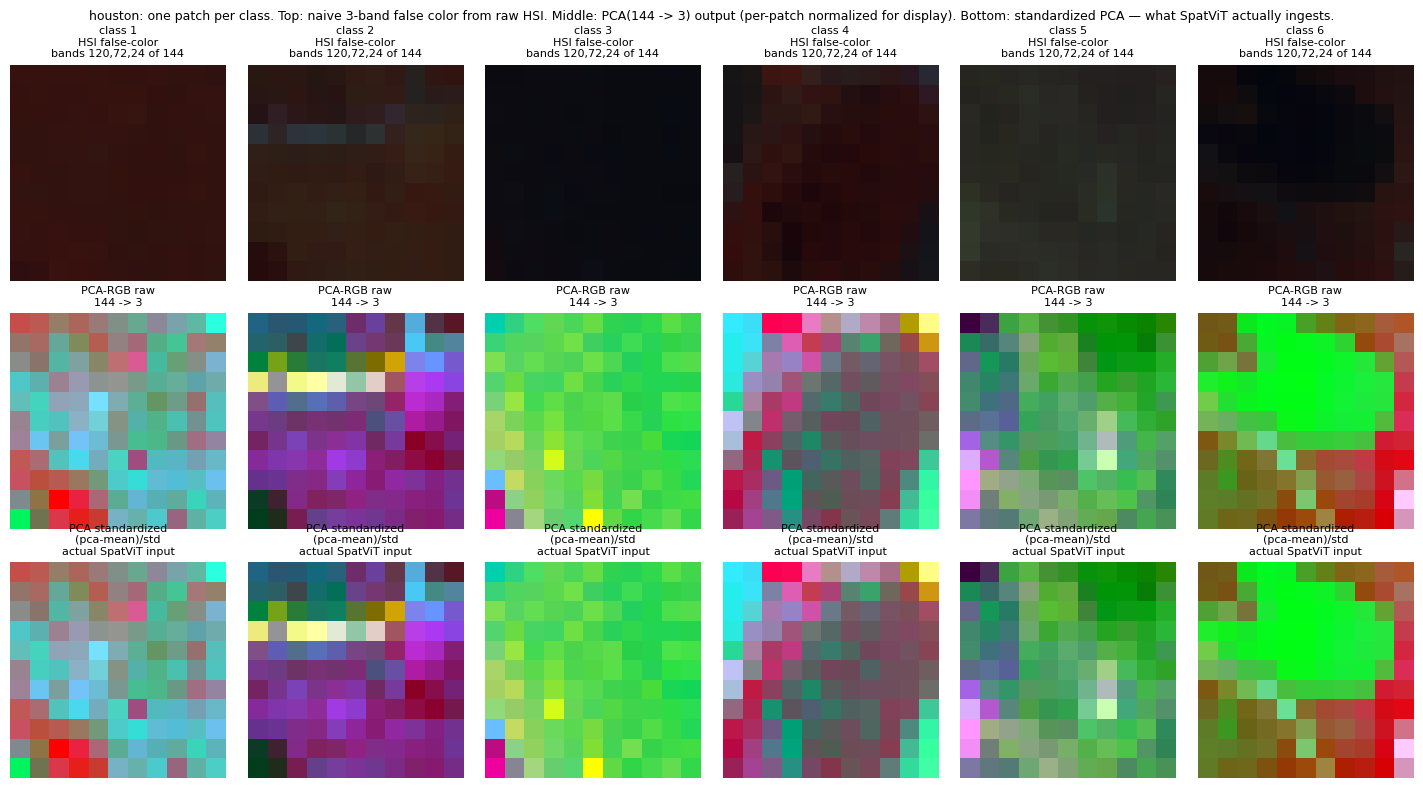

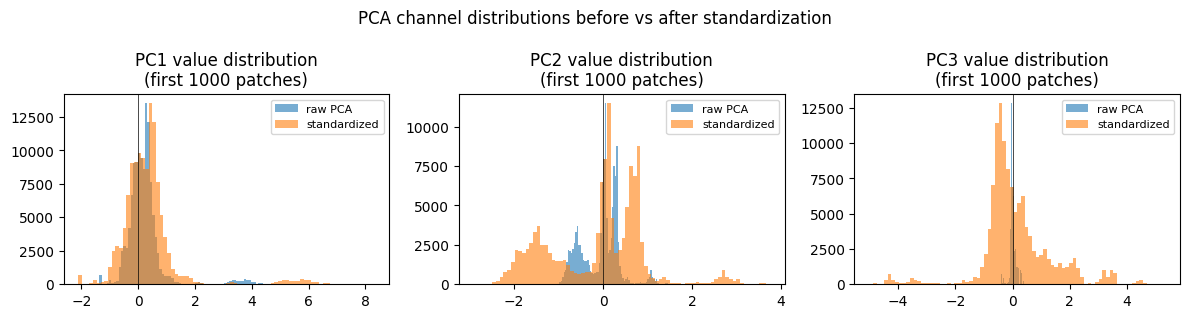

In [4]:
from pathlib import Path
import numpy as np
import torch

from data.datasets import (
    HoustonPatchedDataset,
    TrentoPatchedDataset,
    MUUFLPatchedDataset,
)
from models.hypersigma.preprocessing import (
    DATASET_PCA_CONFIG,
    PCAPreprocessor,
    PCAStandardize,
    fit_dataset_pca,
    fit_pca_output_stats,
    load_pca,
    load_pca_output_stats,
)

DS = {
    "houston": HoustonPatchedDataset,
    "trento": TrentoPatchedDataset,
    "muufl": MUUFLPatchedDataset,
}
ds_name = eval_params["dataset"]
pca_path = Path(eval_params["pca_spat_path"])
stats_path = Path(eval_params["pca_stats_path"]) if eval_params.get("pca_stats_path") else None

dataset = DS[ds_name](
    data_root="./data/raw",
    patch_size=11,
    split="all",
    normalize=True,
)
print(f"Loaded {ds_name}: {len(dataset)} patches, hsi shape={tuple(dataset.hsi.shape)}, "
      f"value range=[{float(dataset.hsi.min()):.3f}, {float(dataset.hsi.max()):.3f}]")

n_components = DATASET_PCA_CONFIG[ds_name]["spat_components"]
n_bands = dataset.hsi.shape[1]

if not pca_path.exists():
    print(f"\nFitting PCA: {n_bands} bands -> {n_components} components ...")
    pca = fit_dataset_pca(
        dataset=dataset,
        n_components=n_components,
        save_path=str(pca_path),
    )
    print(f"Saved to {pca_path}")
else:
    print(f"\nPCA already present at {pca_path} — loading it for inspection.")
    pca = load_pca(str(pca_path))

# --- Per-component explained variance --------------------------------------
print("\nExplained variance per component:")
for i, ev_ratio in enumerate(pca.explained_variance_ratio_):
    bar = "#" * int(round(ev_ratio * 40))
    print(f"  PC{i+1}: {ev_ratio*100:6.2f}%   |{bar}")
cum = float(np.cumsum(pca.explained_variance_ratio_)[-1])
print(f"  Cumulative ({n_components} comps): {cum*100:.2f}%")

# --- Apply the PCA preprocessor end-to-end and show the shape change ------
preproc = PCAPreprocessor(pca)
sample = dataset.hsi[:4]  # [4, C, 11, 11]
with torch.no_grad():
    reduced = preproc(sample)
print(f"\nInput  patch tensor : {tuple(sample.shape)}   "
      f"(B, C={sample.shape[1]} bands, H, W)")
print(f"Output patch tensor : {tuple(reduced.shape)}    "
      f"(B, C={reduced.shape[1]} components, H, W)  -> RGB-like for SpatViT")

# --- Concrete pixel-level example ------------------------------------------
example_pixel = sample[0, :, 5, 5].numpy()
reduced_pixel = reduced[0, :, 5, 5].numpy()
print("\nExample centre pixel (patch[0], y=x=5):")
print(f"  before PCA: {n_bands} bands. First/last 5 = "
      f"{np.array2string(np.concatenate([example_pixel[:5], example_pixel[-5:]]), precision=3)}")
print(f"  after  PCA: {n_components} components -> "
      f"{np.array2string(reduced_pixel, precision=4)}")

reconstructed = pca.inverse_transform(reduced_pixel.reshape(1, -1)).reshape(-1)
rec_mse = float(np.mean((example_pixel - reconstructed) ** 2))
print(f"  reconstruction MSE for this pixel: {rec_mse:.6f}")

# --- Per-class component means (gives a feel for class separability) ------
labels = dataset.labels.numpy()
with torch.no_grad():
    all_reduced = preproc(dataset.hsi[:, :, 5:6, 5:6]).squeeze(-1).squeeze(-1).numpy()
print("\nMean PCA components per class (centre pixel):")
print(f"  {'class':>5s}  {'n':>6s}  " + "  ".join(f"PC{i+1:>1d}".rjust(8) for i in range(n_components)))
for c in sorted(np.unique(labels)):
    mask = labels == c
    means = all_reduced[mask].mean(axis=0)
    print(f"  {c:>5d}  {int(mask.sum()):>6d}  "
          + "  ".join(f"{v:>8.3f}" for v in means))

# --- Fit (or load) PCA-output standardization stats -----------------------
# These stats let HyperSIGMADual apply `pca_out_std = (pca_out - mean) / std`,
# so the SpatViT branch sees inputs with mean=0/std=1 per channel.
# Set eval_params["pca_stats_path"] to None to skip this and feed raw PCA.
if stats_path is None:
    print("\npca_stats_path is None -> SpatViT will receive RAW PCA output (no standardization).")
    stats = None
else:
    if stats_path.exists():
        print(f"\nLoading PCA-output stats from {stats_path}")
        stats = load_pca_output_stats(str(stats_path))
    else:
        print(f"\nFitting PCA-output stats over all {len(dataset)} patches ...")
        stats = fit_pca_output_stats(dataset=dataset, pca=pca, save_path=str(stats_path))
        print(f"Saved to {stats_path}")

    pca_mean = np.asarray(stats["mean"], dtype=np.float32)
    pca_std = np.asarray(stats["std"], dtype=np.float32)
    print(f"  pca_mean  = {np.array2string(pca_mean, precision=4)}")
    print(f"  pca_std   = {np.array2string(pca_std,  precision=4)}")
    print(f"  n_pixels  = {stats['n_pixels']:,}")

    # Build the actual standardize module and forward a quick sanity check
    # so we can show that the math holds: pca_out_std should have mean ~ 0
    # and std ~ 1 per channel over the dataset.
    standardize = PCAStandardize(pca_mean, pca_std)
    with torch.no_grad():
        # Standardize the same 4-patch sample we used above.
        std_sample = standardize(reduced)
        print("\nSanity check on the 4-patch sample (post-standardize per-channel stats):")
        for c in range(n_components):
            ch = std_sample[:, c].flatten().numpy()
            print(f"  PC{c+1}: mean={ch.mean():+.4f}  std={ch.std():.4f}")

        # And over the whole dataset (centre-pixel slice for speed).
        std_all = standardize(preproc(dataset.hsi[:, :, 5:6, 5:6])).squeeze(-1).squeeze(-1).numpy()
        print("Whole-dataset stats (centre-pixel projection):")
        for c in range(n_components):
            print(f"  PC{c+1}: mean={std_all[:, c].mean():+.4f}  std={std_all[:, c].std():.4f}")

# --- Side-by-side patch comparison: HSI false-color vs PCA-RGB vs PCA-std --
try:
    import matplotlib.pyplot as plt

    # Pick one representative patch from each of up to 6 different classes.
    rng = np.random.default_rng(0)
    unique_cls = sorted(np.unique(labels).tolist())
    show_cls = unique_cls[:6]
    chosen_idx = []
    for c in show_cls:
        idxs = np.where(labels == c)[0]
        chosen_idx.append(int(rng.choice(idxs)))

    patches_hsi = dataset.hsi[chosen_idx]                    # [N, C, 11, 11]
    with torch.no_grad():
        patches_pca = preproc(patches_hsi)                   # [N, 3, 11, 11]

    # Build an HSI false-color "before" image by sampling 3 bands evenly.
    band_r, band_g, band_b = (n_bands * 5 // 6, n_bands // 2, n_bands // 6)
    false_color = patches_hsi[:, [band_r, band_g, band_b]].permute(0, 2, 3, 1).numpy()

    # Raw PCA "after" image (per-channel min-max normalized for display).
    pca_rgb = patches_pca.permute(0, 2, 3, 1).numpy()
    pca_rgb_disp = pca_rgb - pca_rgb.min(axis=(1, 2), keepdims=True)
    pca_rgb_disp = pca_rgb_disp / (pca_rgb_disp.max(axis=(1, 2), keepdims=True) + 1e-8)

    # Standardized PCA — the actual tensor SpatViT receives.
    rows = 2
    if stats is not None:
        with torch.no_grad():
            patches_pca_std = standardize(patches_pca)
        pca_std_arr = patches_pca_std.permute(0, 2, 3, 1).numpy()
        # Display: shift+scale per-channel to [0,1] purely for visualization,
        # this does NOT reflect what SpatViT actually sees (it sees raw std values).
        pca_std_disp = pca_std_arr - pca_std_arr.min(axis=(1, 2), keepdims=True)
        pca_std_disp = pca_std_disp / (pca_std_disp.max(axis=(1, 2), keepdims=True) + 1e-8)
        rows = 3

    n = len(chosen_idx)
    fig, axes = plt.subplots(rows, n, figsize=(2.4 * n, 2.5 * rows + 0.5))
    if rows == 1:
        axes = axes[None, :]
    for j in range(n):
        axes[0, j].imshow(false_color[j])
        axes[0, j].set_title(
            f"class {show_cls[j]}\nHSI false-color\nbands {band_r},{band_g},{band_b} of {n_bands}",
            fontsize=8,
        )
        axes[0, j].axis("off")

        axes[1, j].imshow(pca_rgb_disp[j])
        axes[1, j].set_title(f"PCA-RGB raw\n{n_bands} -> {n_components}", fontsize=8)
        axes[1, j].axis("off")

        if stats is not None:
            axes[2, j].imshow(pca_std_disp[j])
            axes[2, j].set_title(
                f"PCA standardized\n(pca-mean)/std\nactual SpatViT input",
                fontsize=8,
            )
            axes[2, j].axis("off")

    subtitle = (
        "Top: naive 3-band false color from raw HSI. "
        "Middle: PCA(144 -> 3) output (per-patch normalized for display). "
    )
    if stats is not None:
        subtitle += "Bottom: standardized PCA — what SpatViT actually ingests."
    else:
        subtitle += "(No standardization configured — SpatViT sees the middle row directly.)"
    fig.suptitle(f"{ds_name}: one patch per class. " + subtitle, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Distribution histograms: raw PCA channels vs standardized PCA channels.
    if stats is not None:
        sample_for_hist = preproc(dataset.hsi[:1000]).numpy()    # [N, 3, H, W]
        sample_std = standardize(torch.from_numpy(sample_for_hist)).numpy()
        fig3, axes3 = plt.subplots(1, n_components, figsize=(4 * n_components, 3.2))
        if n_components == 1:
            axes3 = [axes3]
        for i in range(n_components):
            axes3[i].hist(sample_for_hist[:, i].ravel(), bins=80, alpha=0.6, label="raw PCA")
            axes3[i].hist(sample_std[:, i].ravel(), bins=80, alpha=0.6, label="standardized")
            axes3[i].axvline(0, color="k", linewidth=0.5)
            axes3[i].set_title(f"PC{i+1} value distribution\n(first 1000 patches)")
            axes3[i].legend(fontsize=8)
        fig3.suptitle("PCA channel distributions before vs after standardization")
        plt.tight_layout()
        plt.show()
except Exception as exc:
    print(f"(matplotlib preview skipped: {exc})")

## Step 4 — Inspect the HyperSIGMA dual-branch model

Builds the `HyperSIGMADual` encoder once (loading both pretrained ViT
checkpoints + the PCA you just fit) and shows what's actually in there:
parameter counts (trainable vs frozen), the per-branch tensor shapes from
a real forward pass, and a peek at the SpatViT/SpecViT/SEM components.
Run this whether or not you intend to do MAE adaptation — it surfaces any
shape or checkpoint mismatch *before* you spend hours adapting.

In [ ]:
import logging
from pathlib import Path
import torch

from models.hypersigma.hypersigma_dual import HyperSIGMADual
from pretrain.hypersigma_mae import HyperSIGMAMaskedAdaptation

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    force=True,
)

from data.datasets import get_spec
_spec = get_spec(eval_params["dataset"])
_hsi_channels = _spec.hsi_channels
# Build with the same paths the evaluator / adapter will use.
_pca_path = eval_params["pca_spat_path"]
_spat_ckpt = eval_params["spat_ckpt"]
_spec_ckpt = eval_params["spec_ckpt"]
_stats_path = eval_params.get("pca_stats_path")
for tag, p in [
    ("PCA",     _pca_path),
    ("PCAstats", _stats_path),
    ("SpatViT", _spat_ckpt),
    ("SpecViT", _spec_ckpt),
]:
    if p is None:
        print(f"  {tag:8s} -> (disabled)")
    else:
        print(f"  {tag:8s} -> {p}   {'OK' if Path(p).exists() else 'MISSING'}")
print()

dual = HyperSIGMADual(
    pca_spat_path=_pca_path,
    spat_ckpt=_spat_ckpt,
    spec_ckpt=_spec_ckpt,
    hsi_channels=_hsi_channels,
    spat_patch_k=eval_params.get("spat_patch_k", 3),
    freeze_body=True,
    pca_stats_path=_stats_path,
)

# Structured info log from the model itself (PCA variance, FPN layout, SEM dims, param counts).
dual.log_sanity()

# Show the top-level module tree so the user can see how the pieces wire together.
print("\nDual encoder module tree:")
for name, mod in dual.named_children():
    n_param = sum(p.numel() for p in mod.parameters())
    n_train = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    print(f"  {name:14s}  {type(mod).__name__:32s}  params={n_param:>11,d}  trainable={n_train:>11,d}")

# --- Wrap in the MAE adapter so we can preview per-component param counts
#     and the mode-specific loss/forward path BEFORE committing to a long run.
print()
print(f"Building HyperSIGMAMaskedAdaptation (adapt_mode={adapt_mode!r}, mask_ratio={mask_ratio})")
adapter = HyperSIGMAMaskedAdaptation(
    dual=dual,
    adapt_mode=adapt_mode if adapt_mode is not None else "joint_sem",
    hsi_channels=_hsi_channels,
    patch_size=11,
    mask_ratio=mask_ratio if mask_ratio is not None else 0.75,
)

counts = adapter.parameter_counts()
print("\nParameter counts (per component):")
for k, v in counts.items():
    if k.startswith("total_"):
        continue
    print(f"  {k:24s} {v:>12,d}")
print(f"  {'-' * 36}")
print(f"  {'total_trainable':24s} {counts['total_trainable']:>12,d}")
print(f"  {'total_frozen':24s} {counts['total_frozen']:>12,d}")

# Forward a single dummy patch so the output shapes are visible. The adapter
# samples masks, substitutes mask_tokens via the registered forward hooks,
# runs the encoder, and computes the relevant loss(es).
device = "cuda" if torch.cuda.is_available() else "cpu"
adapter = adapter.to(device).eval()
dummy = torch.randn(2, _hsi_channels, 11, 11, device=device)
with torch.no_grad():
    out_adapt = adapter(dummy)
    out_dual = dual(dummy) if adapter.adapt_mode == "joint_sem" else None

print(f"\nAdapter forward (mode={adapter.adapt_mode}, mask_ratio={adapter.mask_ratio}) on {device}, HSI {tuple(dummy.shape)}:")
print(f"  loss        = {out_adapt['loss'].item():.4f}")
print(f"  loss_spat   = {float(out_adapt['loss_spat']):.4f}")
print(f"  loss_spec   = {float(out_adapt['loss_spec']):.4f}")
print(f"  loss_fused  = {float(out_adapt['loss_fused']):.4f}")
if "mask_spat" in out_adapt:
    m = out_adapt["mask_spat"]
    print(f"  mask_spat   : shape={tuple(m.shape)}, fraction_masked={float(m.mean()):.3f}")
if "mask_spec" in out_adapt:
    m = out_adapt["mask_spec"]
    print(f"  mask_spec   : shape={tuple(m.shape)}, fraction_masked={float(m.mean()):.3f}")
if "pred_spat" in out_adapt:
    print(f"  pred_spat   : {tuple(out_adapt['pred_spat'].shape)}    (B, 16 tokens, 27 px)")
if "pred_spec" in out_adapt:
    print(f"  pred_spec   : {tuple(out_adapt['pred_spec'].shape)}   (B, 100 tokens, 121 px)")
if "pred_fused" in out_adapt:
    print(f"  pred_fused  : {tuple(out_adapt['pred_fused'].shape)}  (B, 3, 11, 11)")

# For joint_sem also show the underlying encoder output shapes.
if out_dual is not None:
    print("\nUnderlying HyperSIGMADual output shapes (joint_sem only):")
    print(f"  fused                : {tuple(out_dual['fused'].shape)}")
    for i, t in enumerate(out_dual["spat_features"]):
        print(f"  spat_features[{i}]    : {tuple(t.shape)}")
    for i, t in enumerate(out_dual["spec_features"]):
        print(f"  spec_features[{i}]    : {tuple(t.shape)}")

# Hooks live on `dual.spat.patch_embed` / `dual.spec.spat_map`; remove them
# now so re-running this cell doesn't accumulate hooks. Step 5 builds its
# own adapter instance and re-registers them cleanly.
adapter.remove_hooks()
del adapter, dual, out_adapt, out_dual, dummy
if device == "cuda":
    torch.cuda.empty_cache()

  PCA      -> checkpoints/hypersigma/pca_trento_3band.pkl   OK
  PCAstats -> checkpoints/hypersigma/pca_trento_3band_stats.pkl   OK
  SpatViT  -> checkpoints/hypersigma/spat-vit-base.pth   OK
  SpecViT  -> checkpoints/hypersigma/spec-vit-base.pth   OK



2026-06-02 18:48:31,418 INFO models.hypersigma.spat_vit_branch: [HyperSIGMA] SpatViT load summary: dropped=5, missing=16 (post-reinit), unexpected=104, pos_embed=interpolated_8x8->4x4
2026-06-02 18:48:31,419 WARNING models.hypersigma.spat_vit_branch: [HyperSIGMA] SpatViT missing keys after re-init (first 10): ['blocks.0.attn.sampling_offsets.weight', 'blocks.0.attn.sampling_offsets.bias', 'blocks.1.attn.sampling_offsets.weight', 'blocks.1.attn.sampling_offsets.bias', 'blocks.3.attn.sampling_offsets.weight', 'blocks.3.attn.sampling_offsets.bias', 'blocks.4.attn.sampling_offsets.weight', 'blocks.4.attn.sampling_offsets.bias', 'blocks.6.attn.sampling_offsets.weight', 'blocks.6.attn.sampling_offsets.bias']
2026-06-02 18:48:31,419 WARNING models.hypersigma.spat_vit_branch: [HyperSIGMA] SpatViT unexpected keys (first 10): ['mask_token', 'decoder_pos_embed', 'decoder_embed.weight', 'decoder_embed.bias', 'decoder_blocks.0.norm1.weight', 'decoder_blocks.0.norm1.bias', 'decoder_blocks.0.attn.qkv


Dual encoder module tree:
  pca_spat        PCAPreprocessor                   params=          0  trainable=          0
  pca_standardize  PCAStandardize                    params=          0  trainable=          0
  spat            SpatViTBranch                     params= 93,228,656  trainable=     33,792
  spec            SpecViTBranch                     params= 86,627,184  trainable=    268,800
  sem             SEM                               params=    509,952  trainable=    509,952
  spec_pool       AdaptiveAvgPool1d                 params=          0  trainable=          0

Building HyperSIGMAMaskedAdaptation (adapt_mode='spatial_only', mask_ratio=0.75)

Parameter counts (per component):
  spat_branch_trainable          33,792
  spat_mask_token                   768
  spat_decoder                  203,803
  ------------------------------------
  total_trainable               238,363
  total_frozen              180,332,000

Adapter forward (mode=spatial_only, mask_ratio=0.75

/work/nmaric/CoFFE/CoFFE/.venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Step 5 — Upstream-faithful MAE adaptation (experiment-style)

Trains the small randomly-initialized HyperSIGMA components via
**upstream-style token-level masked reconstruction**: a learnable
`mask_token` is substituted at masked positions before the encoder, and
the decoder reconstructs **per-patch z-scored pixel targets** (matching
upstream's `norm_pix_loss=True`).

The recipe is selectable via `model.adapt_mode`:

* **`spatial_only`** — only the SpatViT branch is masked + adapted.
  16 spatial tokens, each reconstructing a 3×3×3 = 27-pixel patch.
* **`spectral_only`** — only the SpecViT branch. 100 spectral tokens,
  each reconstructing 121 spatial positions.
* **`joint_sem`** — both branches + SEM + three decoders.
  Loss = `L_spat + L_spec + L_fused` (uniform weights).

### What lands on disk

Following the same pattern as `pretrain.ipynb`, this step writes
**everything** under `experiments/<adapt_experiment_name>/`:

- `pretrain_config.yaml` — frozen copy of the merged config
  (base YAML + your `adapt_extra_overrides` + the standalone `adapt_mode` /
  `mask_ratio` / `adapt_device` toggles).
- `pretrain_overrides.yaml` — just the override dict, for diffing.
- `pretrain_metadata.json` — timestamp, git SHA, resolved device,
  final/best loss, wallclock, parameter counts, the overrides inline.
- `pretrain.log` — full training log including `[HyperSIGMA-MAE]`
  per-component param breakdown at startup and `Saved milestone/interval
  checkpoint:` lines as the run progresses.
- `README.md` — name + description.
- `checkpoints/checkpoint_epoch_*.pth`, `checkpoint.pth` (val-best),
  `checkpoint_final.pth`.

Edit the parameters cell (top of the notebook), then run this cell. To
evaluate the freshly-adapted encoder in Step 6b, set
`adapted_checkpoint = f"experiments/{adapt_experiment_name}/checkpoints/checkpoint.pth"`
in the parameters cell.

> ⚠️ Any old adapted checkpoint from the previous per-(pixel, band)
> Bernoulli recipe is incompatible — the masking, decoder, and loss have
> all changed. Re-run this step before re-evaluating.

In [ ]:
import json
import copy
import logging
from pathlib import Path

run_adaptation = True  # set False to skip Step 5 entirely

if run_adaptation:
    from lib.adapt_runner import run_adapt_hypersigma

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    )

    # Compose the final overrides dict from the standalone variables in the
    # parameters cell PLUS anything in `adapt_extra_overrides`. Deep-merge
    # in Python so a user editing both can see the result before launching.
    def _deep_merge(base, extra):
        out = dict(base)
        for k, v in extra.items():
            if k in out and isinstance(out[k], dict) and isinstance(v, dict):
                out[k] = _deep_merge(out[k], v)
            else:
                out[k] = v
        return out

    overrides = copy.deepcopy(adapt_extra_overrides)
    if adapt_mode is not None:
        overrides = _deep_merge(overrides, {"model": {"adapt_mode": adapt_mode}})
    if mask_ratio is not None:
        overrides = _deep_merge(overrides, {"pretrain": {"mask_ratio": float(mask_ratio)}})
    if adapt_device is not None:
        overrides = _deep_merge(overrides, {"hardware": {"device": adapt_device}})

    exp_dir = Path("experiments") / adapt_experiment_name
    print(f"Adapt experiment    : {adapt_experiment_name}")
    print(f"Description         : {adapt_description}")
    print(f"Base YAML           : {adapt_config_path}")
    print(f"Device              : {adapt_device}")
    print(f"Will be written to  : {exp_dir.resolve()}")
    print(f"Overwrite           : {adapt_overwrite}")
    print(f"\nMerged overrides (deep-merged on top of {adapt_config_path}):")
    print(json.dumps(overrides, indent=2, default=str))
    print()

    # Single call -- packages the entire run under experiments/<name>/ with
    # pretrain_config.yaml, pretrain_overrides.yaml, pretrain_metadata.json,
    # README.md, pretrain.log, and checkpoints/.
    exp = run_adapt_hypersigma(
        name=adapt_experiment_name,
        description=adapt_description,
        config=adapt_config_path,
        overrides=overrides,
        overwrite=adapt_overwrite,
    )

    print("\n" + "=" * 70)
    print(f"Adaptation finished -- experiment dir: {exp.root}")
    print("=" * 70)
    print(f"  status            : {exp.metadata.get('status')}")
    print(f"  resolved_device   : {exp.metadata.get('resolved_device')}"
          f"  ({exp.metadata.get('cuda_device_name', '') or 'cpu'})")
    print(f"  wallclock_seconds : {exp.metadata.get('wallclock_seconds')}")
    print(f"  git_sha           : {exp.metadata.get('git_sha')}")
    hist = exp.metadata.get("history", {})
    if hist:
        print(f"  epochs_run        : {hist.get('epochs_run')}")
        print(f"  final_train_loss  : {hist.get('final_train_loss')}")
        print(f"  best_val_loss     : {hist.get('best_val_loss')}")

    # Surface the on-disk artifacts so the user can browse them in the IDE.
    print("\nOn-disk artifacts:")
    for name in [
        "README.md",
        "pretrain_config.yaml",
        "pretrain_overrides.yaml",
        "pretrain_metadata.json",
        "pretrain.log",
    ]:
        p = exp.root / name
        if p.exists():
            print(f"  {p}  ({p.stat().st_size/1024:.1f} KB)")
    if exp.checkpoints_dir.exists():
        ckpts = sorted(exp.checkpoints_dir.glob("*.pth"))
        print(f"\nCheckpoints ({len(ckpts)} files under {exp.checkpoints_dir}):")
        for p in ckpts:
            print(f"  {p.name}  ({p.stat().st_size/1e6:.1f} MB)")
else:
    print("run_adaptation=False -- skipping Step 5. Set adapted_checkpoint = 'none' above for the unadapted ablation.")

2026-05-21 16:18:17,235 INFO lib.adapt_runner: Starting HyperSIGMA adapt experiment 'hypersigma_adapt_houston_spat_only_run2' at /work/nmaric/CoFFE/CoFFE/experiments/hypersigma_adapt_houston_spat_only_run2
2026-05-21 16:18:17,237 INFO scripts.adapt_hypersigma_houston: Using device: cuda:0 (NVIDIA GeForce RTX 4090)


Adapt experiment    : hypersigma_adapt_houston_spat_only_run2
Description         : HyperSIGMA Level-2 MAE adaptation on Houston. Upstream-faithful token-level masking with learnable mask_token at masked positions and per-patch z-scored reconstruction targets. The single `mode` knob at the top of the notebook controls both adaptation and evaluation: spatial_only|spectral_only|joint_sem.
Base YAML           : configs/pretrain/hypersigma_houston_adapt.yaml
Device              : cuda:0
Will be written to  : /work/nmaric/CoFFE/CoFFE/experiments/hypersigma_adapt_houston_spat_only_run2
Overwrite           : True

Merged overrides (deep-merged on top of configs/pretrain/hypersigma_houston_adapt.yaml):
{
  "pretrain": {
    "epochs": 2000,
    "warmup_epochs": 100,
    "batch_size": 128,
    "lr": 1e-05,
    "min_lr": 5e-07,
    "mask_ratio": 0.75
  },
  "model": {
    "adapt_mode": "spatial_only"
  },
  "hardware": {
    "device": "cuda:0"
  }
}



2026-05-21 16:18:19,294 INFO scripts.adapt_hypersigma_houston: Loaded houston (split=all): 15029 samples
2026-05-21 16:18:20,230 INFO models.hypersigma.spat_vit_branch: [HyperSIGMA] SpatViT load summary: dropped=5, missing=16 (post-reinit), unexpected=104, pos_embed=interpolated_8x8->4x4
2026-05-21 16:18:20,231 WARNING models.hypersigma.spat_vit_branch: [HyperSIGMA] SpatViT missing keys after re-init (first 10): ['blocks.0.attn.sampling_offsets.weight', 'blocks.0.attn.sampling_offsets.bias', 'blocks.1.attn.sampling_offsets.weight', 'blocks.1.attn.sampling_offsets.bias', 'blocks.3.attn.sampling_offsets.weight', 'blocks.3.attn.sampling_offsets.bias', 'blocks.4.attn.sampling_offsets.weight', 'blocks.4.attn.sampling_offsets.bias', 'blocks.6.attn.sampling_offsets.weight', 'blocks.6.attn.sampling_offsets.bias']
2026-05-21 16:18:20,231 WARNING models.hypersigma.spat_vit_branch: [HyperSIGMA] SpatViT unexpected keys (first 10): ['mask_token', 'decoder_pos_embed', 'decoder_embed.weight', 'decode

## Step 6a — Bootstrap the umbrella experiment dir (only the first time)

Creates `experiments/<experiment_name>/` so all of this run's evaluations
land in one place. Subsequent re-evals reuse the existing directory.

In [4]:
from lib.experiments import ExperimentLogger
logger_ = ExperimentLogger(repo_root=REPO)
try:
    logger_.get_experiment(experiment_name)
    print(f"Experiment '{experiment_name}' already exists")
except FileNotFoundError:
    logger_.start_pretrain(
        name=experiment_name,
        description=(
            "HyperSIGMA baseline: SpatViT_fusion_patch + SpecViT_fusion + four-stage SEM, "
            "Houston Level-2 MAE adaptation on the small randomly-init components."
        ),
        config={"meta": "hypersigma baseline; pretraining is upstream + Houston adaptation"},
    )
    print(f"Created experiment '{experiment_name}'")

Experiment 'hypersigma_muufl_spectral_only_run1' already exists


## Step 6b — Run few-shot evaluation

Dispatches to `scripts.evaluate_hypersigma.run_evaluation`, which
samples `num_episodes` episodes of n-way / k-shot / k-query, computes
prototypes from the frozen (optionally adapted) HyperSIGMA features, and
classifies the query set with the requested distance metric. Results land
in `experiments/<experiment_name>/evaluations/<eval_name>/`
(`results.json`, `metadata.json`, `eval.log`, `plots/`).

In [5]:
from lib.eval_runner import run_hypersigma_evaluation

ev = run_hypersigma_evaluation(
    experiment_name=experiment_name,
    eval_name=eval_name,
    adapted_checkpoint=adapted_checkpoint,
    eval_params=eval_params,
    overwrite=overwrite,
)
print("Eval dir:", ev.root)

/work/nmaric/CoFFE/CoFFE/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2026-06-10 21:30:52,316 - Starting HyperSIGMA eval 'hypersigma_muufl_C11way_5shot_adapted_spectral_only_run1' for experiment 'hypersigma_muufl_spectral_only_run1'
2026-06-10 21:30:52,317 - Using device: cuda:2
2026-06-10 21:30:52,318 - Resolved paths: pca_spat=checkpoints/hypersigma/pca_muufl_3band.pkl pca_stats=checkpoints/hypersigma/pca_muufl_3band_stats.pkl adapted=experiments/hypersigma_adapt_muufl_spectral_only_run1/checkpoints/checkpoint_final.pth
2026-06-10 21:30:56,698 - Loaded muufl (all): 53687 samples
2026-06-10 21:30:58,138 - [HyperSIGMA] SpecViT load summary: dropped=3, missing=16, unexpected=104, pos_embed=loaded
2026-06-10 21:30:58,139 - [HyperSIGMA] SpecViT missing keys (first 10)

Eval dir: /work/nmaric/CoFFE/CoFFE/experiments/hypersigma_muufl_spectral_only_run1/evaluations/hypersigma_muufl_C11way_5shot_adapted_spectral_only_run1


## Step 7 — Inspect evaluation results

Prints the headline OA/AA/Kappa for both cosine and euclidean distance,
plus per-class accuracy and a listing of every plot file written under
`experiments/<exp>/evaluations/<eval>/plots/`.

In [6]:
import json
from pathlib import Path

print("=" * 70)
print(f"Evaluation directory: {ev.root}")
print("=" * 70)

summary = ev.metadata.get("summary", {})
print("\nSummary (primary metric, written to metadata.json):")
print(json.dumps(summary, indent=2, default=str))

results = json.loads(ev.results_path.read_text())

# Headline OA / AA / Kappa for both distances.
print("\n" + "-" * 70)
print(f"{'Distance':<10s}  {'OA':>16s}  {'AA':>16s}  {'Kappa':>16s}")
print("-" * 70)
for metric in ("cosine", "euclidean"):
    block = results.get(metric, {})
    if not block:
        continue
    oa = block.get("OA", {})
    aa = block.get("AA", {})
    kp = block.get("Kappa", {})
    print(
        f"{metric.upper():<10s}  "
        f"{oa.get('mean', float('nan')):>6.2f} +/- {oa.get('ci_95', 0):<5.2f}  "
        f"{aa.get('mean', float('nan')):>6.2f} +/- {aa.get('ci_95', 0):<5.2f}  "
        f"{kp.get('mean', float('nan')):>6.2f} +/- {kp.get('ci_95', 0):<5.2f}"
    )

# Per-class accuracy (primary distance only — these tables get long).
primary = eval_params.get("distance_metric", "euclidean")
primary_block = results.get(primary, {})
per_class = primary_block.get("per_class_accuracy")
if per_class:
    print("\n" + "-" * 70)
    print(f"Per-class accuracy ({primary}, mean +/- CI95):")
    print("-" * 70)
    items = per_class.items() if isinstance(per_class, dict) else enumerate(per_class)
    for k, v in items:
        if isinstance(v, dict):
            print(f"  class {k!s:>3s}: {v.get('mean', float('nan')):>6.2f} +/- {v.get('ci_95', 0):.2f}")
        else:
            print(f"  class {k!s:>3s}: {v:>6.2f}")

# Show what plot files were written so the user can open them from the file tree.
plots_dir = Path(ev.plots_dir) if hasattr(ev, "plots_dir") else (Path(ev.root) / "plots")
if plots_dir.exists():
    plot_files = sorted(plots_dir.glob("*"))
    print("\n" + "-" * 70)
    print(f"Plot files in {plots_dir} ({len(plot_files)} files):")
    print("-" * 70)
    for p in plot_files:
        print(f"  {p.name}  ({p.stat().st_size/1024:.1f} KB)")


Evaluation directory: /work/nmaric/CoFFE/CoFFE/experiments/hypersigma_muufl_spectral_only_run1/evaluations/hypersigma_muufl_C11way_5shot_adapted_spectral_only_run1

Summary (primary metric, written to metadata.json):
{
  "OA": {
    "mean": 20.700863636363636,
    "std": 2.00614986246321,
    "ci_95": 0.08797504573729065
  },
  "AA": {
    "mean": 20.700863636363636,
    "std": 2.00614986246321,
    "ci_95": 0.08797504573729065
  },
  "Kappa": {
    "mean": 12.770950000000001,
    "std": 2.2067648487095313,
    "ci_95": 0.09677255031101972
  },
  "num_episodes": 2000
}

----------------------------------------------------------------------
Distance                  OA                AA             Kappa
----------------------------------------------------------------------
COSINE       15.63 +/- 0.09    15.63 +/- 0.09     7.19 +/- 0.10 
EUCLIDEAN    20.70 +/- 0.09    20.70 +/- 0.09    12.77 +/- 0.10 

----------------------------------------------------------------------
Plot files in 

In [9]:
import gc, torch

# Drop any Python references to the model/runner first
del exp

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()  # optional, releases shared memory handles

# Confirm it actually freed
print(torch.cuda.memory_summary(device=device, abbreviated=True))


NameError: name 'exp' is not defined